In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)

Dataset description

In [44]:
df=pd.read_csv('train.csv')
df

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt,51.549053
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,53.008323
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,48.621527
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,44.156984
...,...,...,...,...,...,...,...,...,...,...,...,...
906,1044,2022-03-29,395,18,17.354199,45.138435,1,0,40.550668,Intermediate,GRAINS,50.369152
907,1045,2022-11-27,483,11,24.912137,59.485091,6,0,36.470276,intermediate,dairy,43.070121
908,1046,2023-04-12,243,11,28.870945,70.508404,2,0,19.767203,Intermediate,MeAt,29.632560
909,1048,2022-02-14,406,10,19.061638,55.286642,0,0,28.560361,EXPERT,MEAT,44.615759


In [45]:
#df.drop(['ID','date'],axis=1,inplace=True)
#df

In [46]:
df['waste_category'] = df['waste_category'].str.lower()
df['staff_experience']=df['staff_experience'].str.lower()
df['staff_experience'] = df['staff_experience'].replace('nan', np.nan)

In [47]:
df

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,meat,51.549053
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,beginner,meat,53.008323
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,beginner,meat,48.621527
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,intermediate,meat,44.156984
...,...,...,...,...,...,...,...,...,...,...,...,...
906,1044,2022-03-29,395,18,17.354199,45.138435,1,0,40.550668,intermediate,grains,50.369152
907,1045,2022-11-27,483,11,24.912137,59.485091,6,0,36.470276,intermediate,dairy,43.070121
908,1046,2023-04-12,243,11,28.870945,70.508404,2,0,19.767203,intermediate,meat,29.632560
909,1048,2022-02-14,406,10,19.061638,55.286642,0,0,28.560361,expert,meat,44.615759


In [48]:
df.shape

(911, 12)

In [49]:
print(df.dtypes)

ID                    int64
date                 object
meals_served          int64
kitchen_staff         int64
temperature_C       float64
humidity_percent    float64
day_of_week           int64
special_event         int64
past_waste_kg       float64
staff_experience     object
waste_category       object
food_waste_kg       float64
dtype: object


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.select_dtypes(exclude='object').skew()

,0
ID,-0.015749
meals_served,6.581128
kitchen_staff,0.020202
temperature_C,0.111854
humidity_percent,-0.093234
day_of_week,-0.008186
special_event,2.966833
past_waste_kg,0.016268
food_waste_kg,4.990900


In [52]:
df.isnull().sum()

,0
ID,0
date,0
meals_served,0
kitchen_staff,0
temperature_C,0
humidity_percent,0
day_of_week,0
special_event,0
past_waste_kg,0
staff_experience,164


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 85.5+ KB


In [54]:
df.describe()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg
count,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,528.327113,375.405049,11.900110,22.189280,60.761313,3.014270,0.085620,27.015691,44.842691
std,305.072794,502.812717,4.285153,8.922389,17.330821,2.009542,0.279956,12.774223,27.934366
min,0.000000,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394,10.819048
25%,266.000000,211.000000,8.000000,15.684585,46.017835,1.000000,0.000000,16.091383,32.887912
50%,531.000000,306.000000,12.000000,22.115040,61.633960,3.000000,0.000000,26.854109,41.146930
75%,795.500000,407.000000,15.000000,28.804294,75.787910,5.000000,0.000000,38.149878,50.046681
max,1049.000000,4730.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703,274.328783


EDA

<Axes: xlabel='waste_category', ylabel='count'>

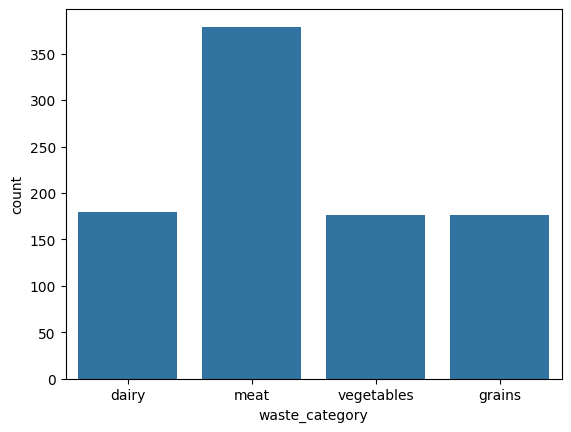

In [55]:
sns.countplot(data = df , x=df['waste_category'])

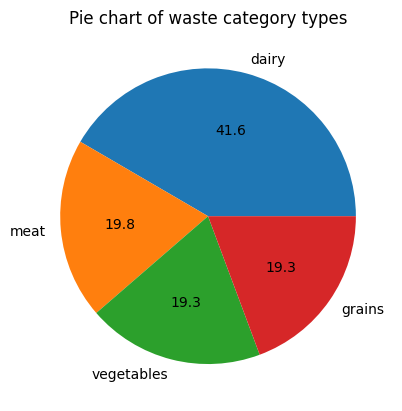

In [56]:
waste_category_count =  df['waste_category'].value_counts()

waste_category_label = df['waste_category'].unique()

plt.pie(waste_category_count, labels = waste_category_label, autopct="%1.1f")
plt.title('Pie chart of waste category types')
plt.show()

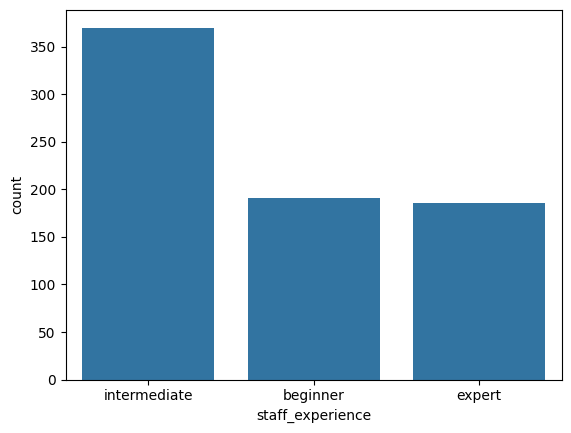

In [57]:
sns.countplot(data = df , x=df['staff_experience'])
plt.show()

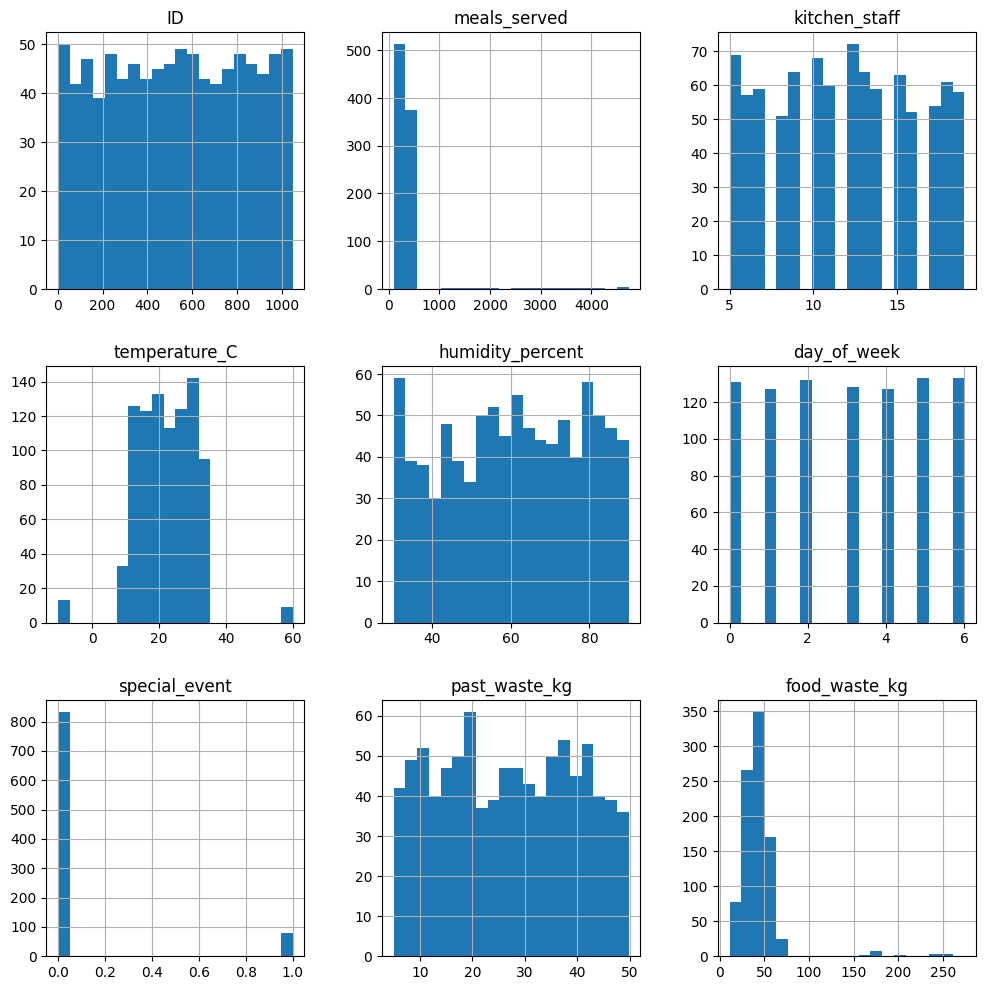

In [58]:
df.select_dtypes(exclude='object').hist(figsize=(12,12),bins=20)
plt.show()

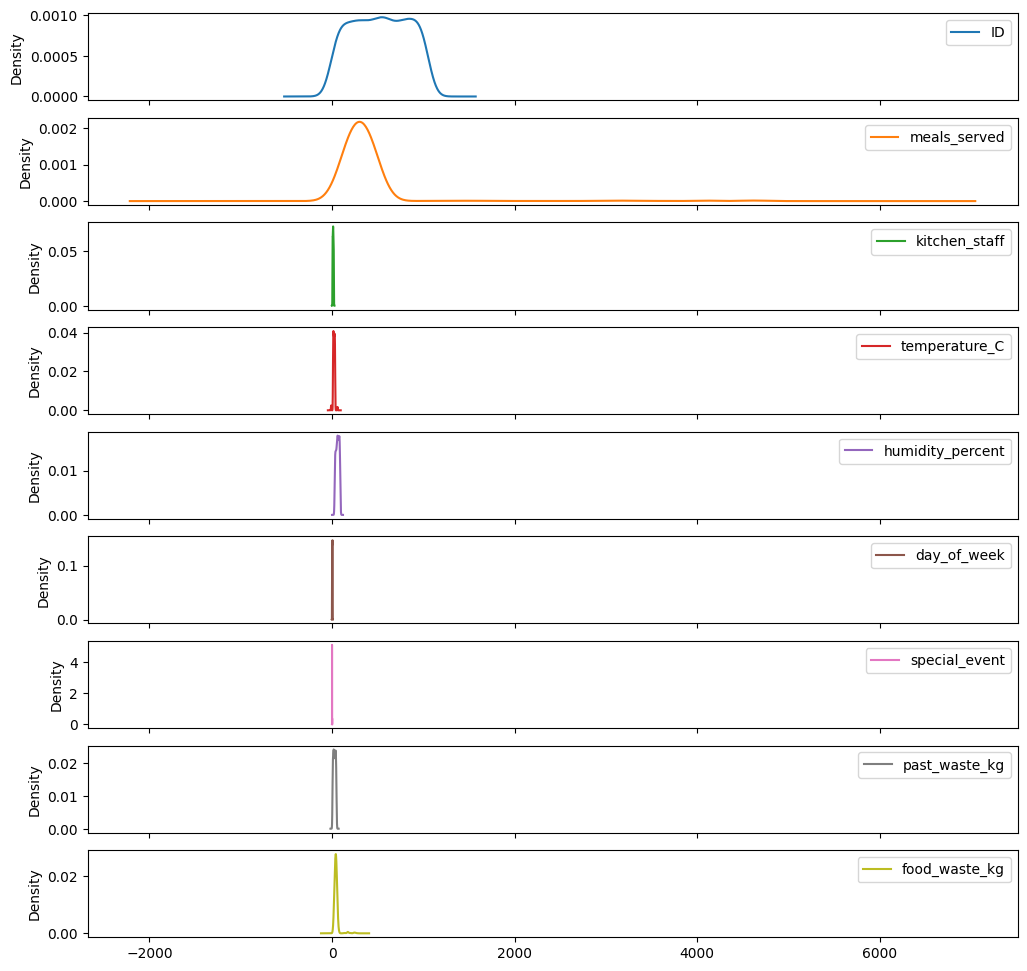

In [59]:
df.select_dtypes(exclude='object').plot.kde(figsize=(12, 12), subplots=True)
plt.show()

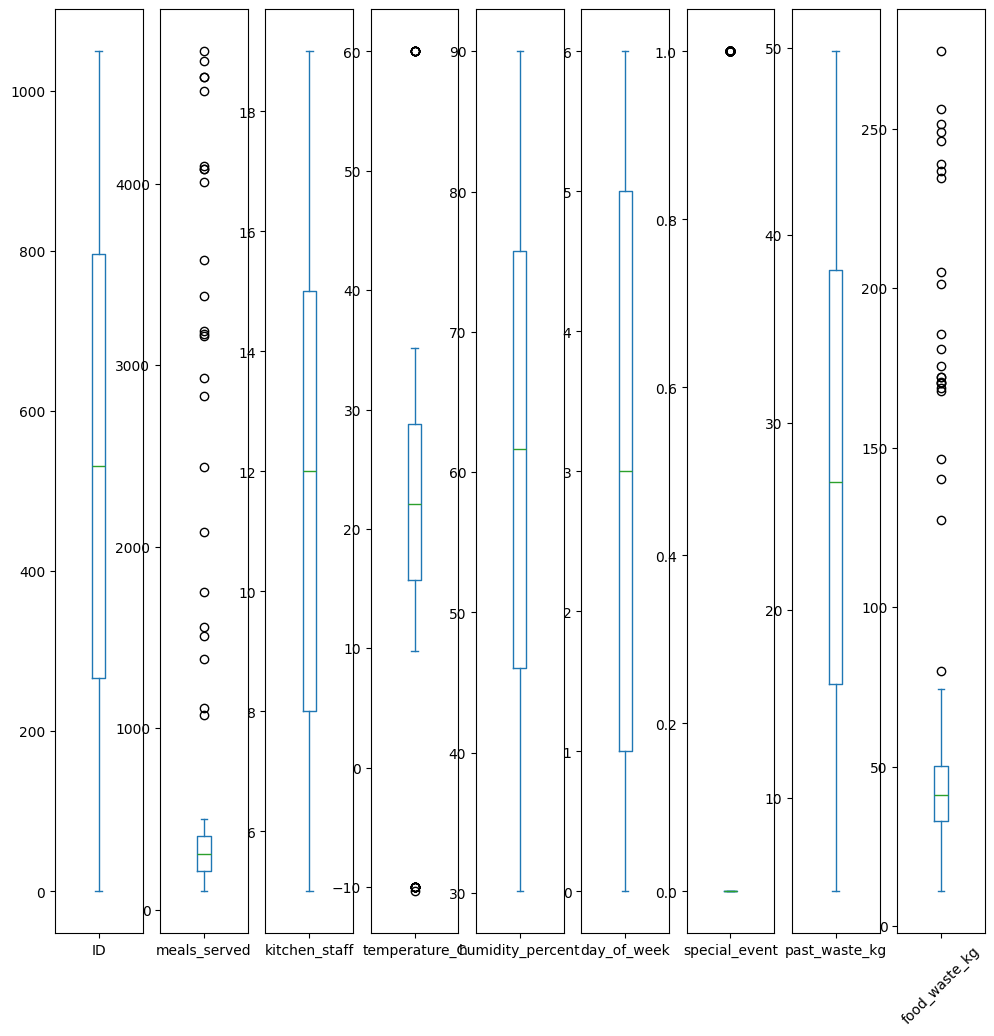

In [60]:
df.select_dtypes(exclude='object').plot.box(figsize=(12, 12), subplots=True)
plt.xticks(rotation=45)
plt.show()

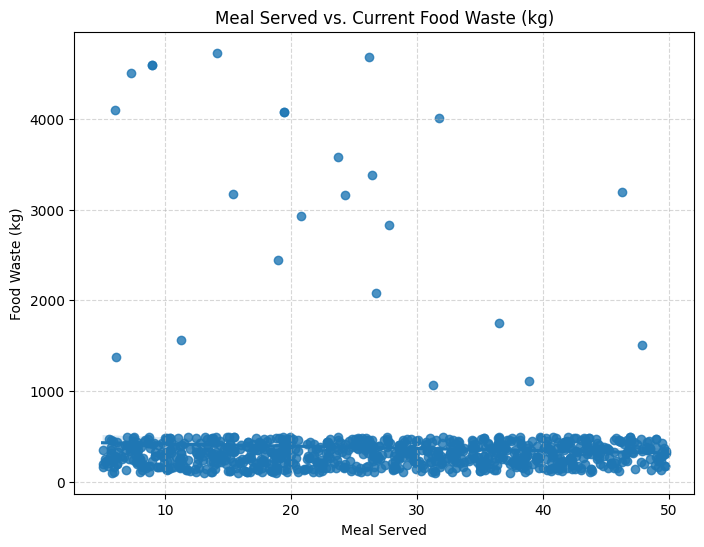

In [61]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='past_waste_kg',
    y='meals_served')
plt.title('Meal Served vs. Current Food Waste (kg)')
plt.xlabel('Meal Served')
plt.ylabel('Food Waste (kg)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_7134/2858690080.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='waste_category', y='food_waste_kg',ci=None)


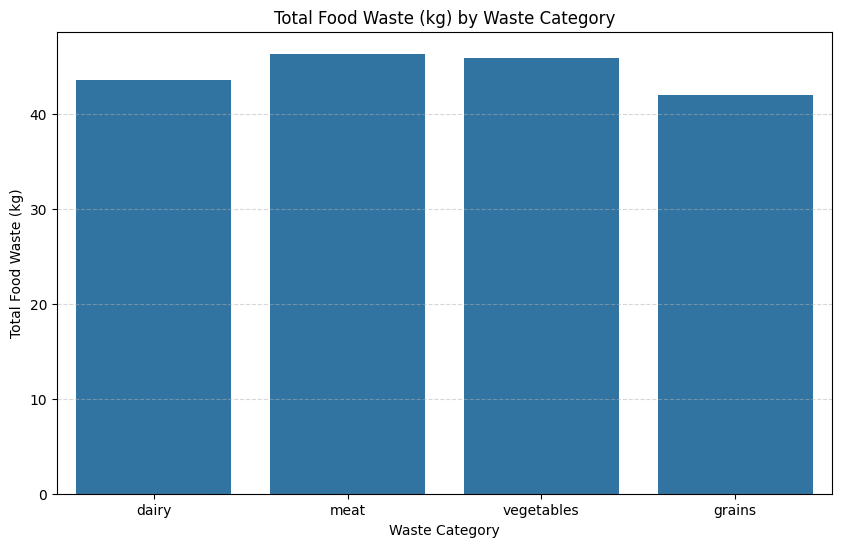

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='waste_category', y='food_waste_kg',ci=None)
plt.title('Total Food Waste (kg) by Waste Category')
plt.xlabel('Waste Category')
plt.ylabel('Total Food Waste (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

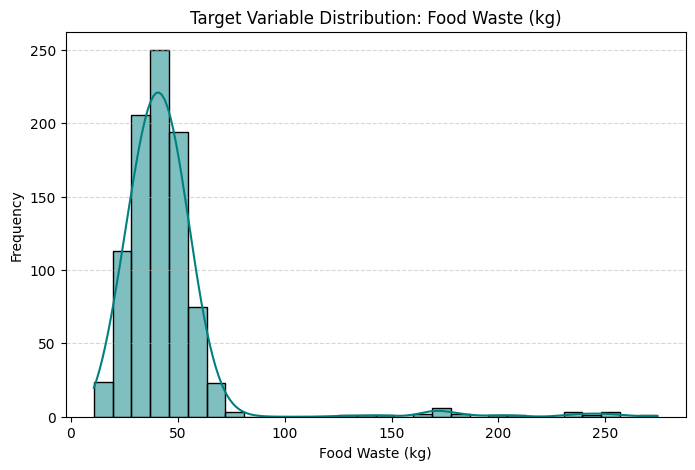

In [63]:
plt.figure(figsize=(8, 5))
sns.histplot(df['food_waste_kg'], kde=True, bins=30, color='teal')
plt.title('Target Variable Distribution: Food Waste (kg)')
plt.xlabel('Food Waste (kg)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

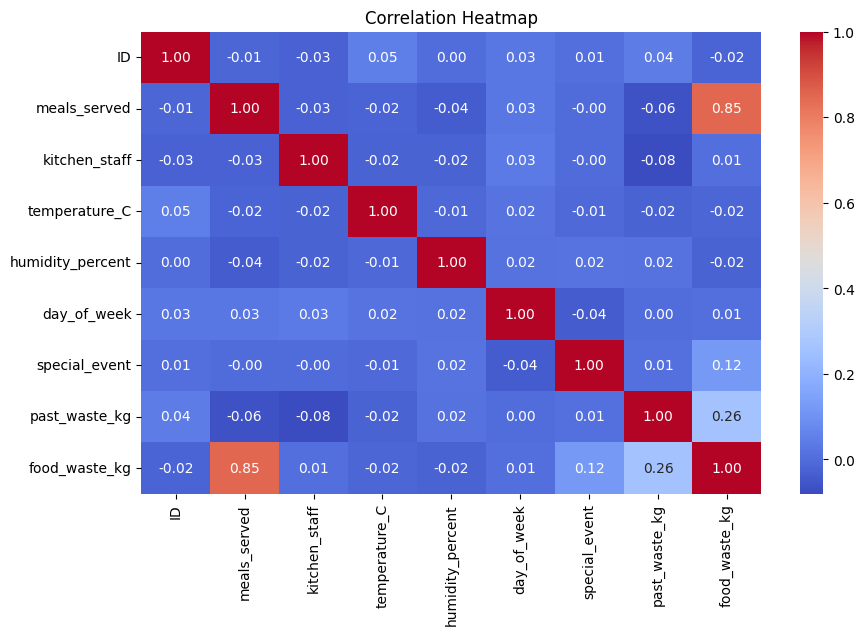

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Dataset pre-processing**

In [65]:
X=df.drop(['ID','date','food_waste_kg'],axis=1)
X

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
0,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy
1,244,15,10.317872,64.430475,1,0,42.311779,NaN,meat
2,148,16,27.714300,69.046113,1,0,41.184305,beginner,meat
3,157,19,19.173902,46.292823,6,0,41.543492,beginner,meat
4,297,10,26.375233,79.741064,0,0,26.525097,intermediate,meat
...,...,...,...,...,...,...,...,...,...
906,395,18,17.354199,45.138435,1,0,40.550668,intermediate,grains
907,483,11,24.912137,59.485091,6,0,36.470276,intermediate,dairy
908,243,11,28.870945,70.508404,2,0,19.767203,intermediate,meat
909,406,10,19.061638,55.286642,0,0,28.560361,expert,meat


In [66]:
y=df['food_waste_kg']
y

,food_waste_kg
0,28.946465
1,51.549053
2,53.008323
3,48.621527
4,44.156984
...,...
906,50.369152
907,43.070121
908,29.632560
909,44.615759


In [67]:

cat_cols= X.select_dtypes(include=['object']).columns

num_cols= X.select_dtypes(exclude='object').columns

print(f'Categorical Columns: {cat_cols}')
print(f'Numerical Columns: {num_cols}')

Categorical Columns: Index(['staff_experience', 'waste_category'], dtype='object')
Numerical Columns: Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'special_event', 'past_waste_kg'],
      dtype='object')


In [68]:
df.isnull().sum()

,0
ID,0
date,0
meals_served,0
kitchen_staff,0
temperature_C,0
humidity_percent,0
day_of_week,0
special_event,0
past_waste_kg,0
staff_experience,164


In [69]:
for cols in cat_cols:
    print(X[cols].unique())

['intermediate' nan 'beginner' 'expert']
['dairy' 'meat' 'vegetables' 'grains']


In [70]:
X[num_cols].describe()

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg
count,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,375.405049,11.900110,22.189280,60.761313,3.014270,0.085620,27.015691
std,502.812717,4.285153,8.922389,17.330821,2.009542,0.279956,12.774223
min,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394
25%,211.000000,8.000000,15.684585,46.017835,1.000000,0.000000,16.091383
50%,306.000000,12.000000,22.115040,61.633960,3.000000,0.000000,26.854109
75%,407.000000,15.000000,28.804294,75.787910,5.000000,0.000000,38.149878
max,4730.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703


In [71]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'special_event', 'past_waste_kg'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['staff_experience', 'waste_category'], dtype='object'))])

**Dataset splitting**

In [112]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42
                                               )

In [73]:
X_train

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
25,464,11,12.722959,58.589003,6,0,23.698133,intermediate,vegetables
84,440,7,24.326036,71.282667,2,0,33.333276,intermediate,dairy
10,487,15,20.965180,53.392341,2,0,41.075793,expert,meat
342,496,16,28.648130,86.952518,3,0,40.833530,expert,dairy
889,324,13,22.621122,65.921544,5,0,47.092017,beginner,meat
...,...,...,...,...,...,...,...,...,...
106,273,6,24.838464,71.865377,0,0,36.815688,intermediate,vegetables
270,246,17,27.149193,80.128814,5,0,27.068383,beginner,dairy
860,207,6,21.421466,34.962928,4,1,41.557583,intermediate,vegetables
435,291,19,19.501863,82.322900,1,0,27.253451,beginner,meat


In [74]:
X_test

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
704,147,18,15.976383,63.124162,4,0,41.924846,intermediate,meat
760,164,18,16.634685,47.468655,1,1,26.541719,expert,meat
545,339,7,18.494437,72.227539,2,0,19.219871,intermediate,vegetables
367,326,5,30.536018,81.248160,0,0,12.743871,intermediate,vegetables
361,157,6,22.209853,80.750973,3,0,24.169888,NaN,grains
...,...,...,...,...,...,...,...,...,...
344,483,14,20.954309,32.278894,6,0,36.532648,beginner,vegetables
581,185,13,10.521528,79.775253,1,0,30.510176,intermediate,meat
893,219,10,21.872164,45.253883,3,0,5.231283,intermediate,meat
449,125,17,15.880890,31.321615,4,0,21.045710,expert,grains


In [75]:
y_train

,food_waste_kg
25,45.685086
84,50.206672
10,61.213326
342,65.382811
889,60.625869
...,...
106,37.967789
270,44.271496
860,56.541504
435,41.359468


In [76]:
y_test

,food_waste_kg
704,34.490746
760,38.151336
545,33.296392
367,30.037758
361,40.008565
...,...
344,59.746432
581,42.843562
893,28.297747
449,19.286385


**Model training & testing (Supervised)**

Linear Regression

In [126]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_pipeline,
    X ,
    y,
    cv = kf ,
    scoring = "r2"
)

print("Scores ", cv_scores)
print("Average Cv 42", cv_scores.mean())

Scores  [0.74404408 0.86148775 0.89266699 0.84975646 0.71807591]
Average Cv 42 0.8132062351458457


In [128]:
lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'special_event', 'past_waste_kg'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['staff_experience', 'waste_category'], dtype='object'))])),
                ('model', LinearRegression())])

In [129]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_lr

array([ 45.52061206,  50.13349476,  34.15018841,  29.18513134,
        28.41228254,  37.23362646,  52.73875906,  54.68955128,
        40.8960745 ,  57.34232224,  35.67122192,  39.14998692,
        34.97379336,  25.2715496 ,  37.06815519,  38.38792456,
        43.0677618 ,  20.5841468 ,  38.10055776,  41.60490032,
        55.53863501,  46.8548488 ,  44.83181176,  35.74782153,
        44.18486309,  32.28223712,  53.79596713,  39.76945041,
        45.56108723,  48.85988951,  53.33085414,  50.08416023,
        33.83086862,  29.11955699,  53.21792949,  29.78529257,
        50.70640947,  48.44816325,  53.96943551,  50.1786247 ,
        43.15729584,  35.34347834,  20.75730628,  25.4252229 ,
        33.31299393,  51.93910055,  36.3937295 ,  30.35583295,
        64.23299502,  34.44942761,  55.79214414,  44.15119752,
        36.51876775,  20.49336809,  52.70250017,  39.2430919 ,
        56.60529616,  27.51328263,  48.62482926,  42.37224228,
        58.52553757,  55.40338472,  48.2434046 ,  56.49

In [131]:
mse_lr= mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
lr_r2=r2_score(y_test,y_pred_lr)
print(f"R2 Score: {lr_r2:.4f}")
print(f"MSE Loss: {mse_lr:.4f}")
print(f"RMSE Loss: {rmse_lr:.4f}")
print(f"MAE Loss:  {mae_lr:.4f}")

R2 Score: 0.7440
MSE Loss: 131.1437
RMSE Loss: 11.4518
MAE Loss:  5.6193


Decision Tree Classifier

In [122]:
dt_pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , DecisionTreeRegressor(max_depth=5,min_samples_split=10,random_state=42))
    ]
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    dt_pipeline,
    X ,
    y,
    cv = kf ,
    scoring = "r2"
)

print("Scores ", cv_scores)
print("Average Cv 42", cv_scores.mean())

Scores  [0.71619418 0.8618438  0.8063285  0.75975574 0.87947434]
Average Cv 42 0.8047193122680547


In [123]:
dt_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'special_event', 'past_waste_kg'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['staff_experience', 'waste_category'], dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=5, min_samples_split=10,
                                       random_state=42))])

In [124]:
y_pred_dt = dt_pipeline.predict(X_test)
y_pred_dt

array([ 46.19665266,  35.07857636,  34.22982257,  34.22982257,
        31.98291686,  34.22982257,  46.19665266,  57.44883345,
        34.22982257,  57.44883345,  42.18408438,  35.07857636,
        34.22982257,  24.53450792,  34.22982257,  40.70169574,
        42.18408438,  24.53450792,  34.22982257,  42.18408438,
        57.44883345,  48.4991646 ,  49.99862637,  34.22982257,
        46.19665266,  35.07857636,  46.19665266,  42.18408438,
        46.19665266,  48.4991646 ,  48.4991646 ,  46.19665266,
        31.98291686,  31.98291686,  46.19665266,  24.53450792,
        48.4991646 ,  42.11744293,  48.4991646 ,  49.99862637,
        42.18408438,  35.07857636,  24.53450792,  24.53450792,
        34.22982257,  48.4991646 ,  31.98291686,  31.98291686,
        57.44883345,  35.07857636,  57.44883345,  42.18408438,
        40.70169574,  24.53450792,  57.44883345,  42.18408438,
        46.19665266,  31.98291686,  49.99862637,  42.18408438,
        57.44883345,  57.44883345,  48.4991646 ,  49.99

In [125]:
mse_dt= mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
dt_r2=r2_score(y_test,y_pred_dt)
print(f"R2 Score: {dt_r2:.4f}")
print(f"MSE Loss: {mse_dt:.4f}")
print(f"RMSE Loss: {rmse_dt:.4f}")
print(f"MAE Loss:  {mae_dt:.4f}")

R2 Score: 0.7162
MSE Loss: 145.4131
RMSE Loss: 12.0587
MAE Loss:  6.2138


Neural Networks

In [92]:
import warnings
warnings.filterwarnings('ignore')

In [95]:
from sklearn.neural_network import MLPRegressor

nn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    nn_pipeline,
    X ,
    y,
    cv = kf ,
    scoring = "r2"
)
nn_r2=cv_scores.mean()
print("Scores ", cv_scores)
print("Average Cv 42", nn_r2)


Scores  [0.85175658 0.90622608 0.87519536 0.90447468 0.80547859]
Average Cv 42 0.8686262571687221


In [118]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings('ignore', category=ConvergenceWarning)

nn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(nn_pipeline, X, y, cv=kf, scoring="r2")

print("Scores:", cv_scores)
print("Average CV R2 Score:", cv_scores.mean())



Scores: [0.85175658 0.90622608 0.87519536 0.90447468 0.80547859]
Average CV R2 Score: 0.8686262571687221


In [119]:
nn_pipeline.fit(X_train,y_train)
y_pred_nn = nn_pipeline.predict(X_test)
y_pred_nn

array([ 38.25684962,  46.08905531,  31.82825679,  28.13901367,
        28.09016089,  38.83607766,  50.75383386,  57.65155543,
        43.95009365,  58.9044588 ,  35.8914146 ,  32.30571115,
        35.08362963,  21.84382545,  35.57318731,  34.27223692,
        41.59375354,  23.47847288,  36.05794582,  41.32615736,
        56.01931229,  47.8725684 ,  51.70792275,  38.32446761,
        37.72703581,  30.02257161,  53.40189387,  34.48058658,
        43.94504913,  50.53788109,  58.70682309,  48.46987863,
        29.80220933,  27.54529991,  50.70373728,  29.76039196,
        50.78893874,  44.1231422 ,  53.74344373,  48.88427318,
        44.61968949,  34.4962051 ,  24.46692444,  22.64332422,
        29.84517514,  59.30215859,  33.7946779 ,  28.27748431,
        68.94392521,  29.89052664,  55.97993004,  43.49530162,
        36.57268344,  23.63520717,  55.94613077,  41.25759108,
        60.07159809,  23.80867137,  43.52326371,  41.29877907,
        61.58890635,  60.61726618,  52.12582689,  56.55

In [121]:
mse_nn= mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
mae_nn= mean_absolute_error(y_test, y_pred_nn)
nn_r2=r2_score(y_test,y_pred_nn)

print(f"R2 Score: {nn_r2:.4f}")
print(f"MSE Loss: {mse_nn:.4f}")
print(f"RMSE Loss: {rmse_nn:.4f}")
print(f"MAE Loss:  {mae_nn:.4f}")

R2 Score: 0.8480
MSE Loss: 77.8676
RMSE Loss: 8.8243
MAE Loss:  5.4158


KMeans

In [132]:
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(n_clusters=3,
                init = 'k-means++',
                max_iter = 400,
                random_state=42))
])
kmeans_pipeline.fit(X)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent',
       'day_of_week', 'special_event', 'past_waste_kg'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['staff_experience', 'waste_category'], dtype='object'))])),
                ('model', KMeans(max_iter=400, n_clusters=3, random_state=42))])

In [133]:
df['Cluster']=kmeans_pipeline.predict(X)

In [134]:
df

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg,Cluster
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465,1
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,meat,51.549053,0
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,beginner,meat,53.008323,0
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,beginner,meat,48.621527,0
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,intermediate,meat,44.156984,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,1044,2022-03-29,395,18,17.354199,45.138435,1,0,40.550668,intermediate,grains,50.369152,0
907,1045,2022-11-27,483,11,24.912137,59.485091,6,0,36.470276,intermediate,dairy,43.070121,0
908,1046,2023-04-12,243,11,28.870945,70.508404,2,0,19.767203,intermediate,meat,29.632560,2
909,1048,2022-02-14,406,10,19.061638,55.286642,0,0,28.560361,expert,meat,44.615759,1


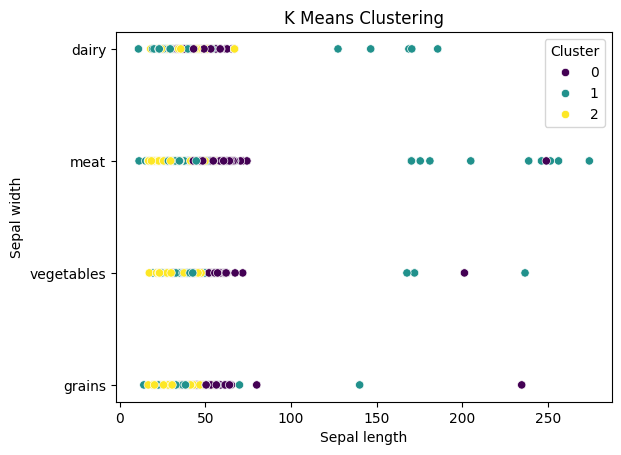

In [135]:
sns.scatterplot(
    x = df['food_waste_kg'],
    y=df['waste_category'],
    hue = df['Cluster'],
    palette = 'viridis'
)

plt.title("K Means Clustering")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.show()

Samples per cluster:
cluster
1    422
2    411
0     78
Name: count, dtype: int64


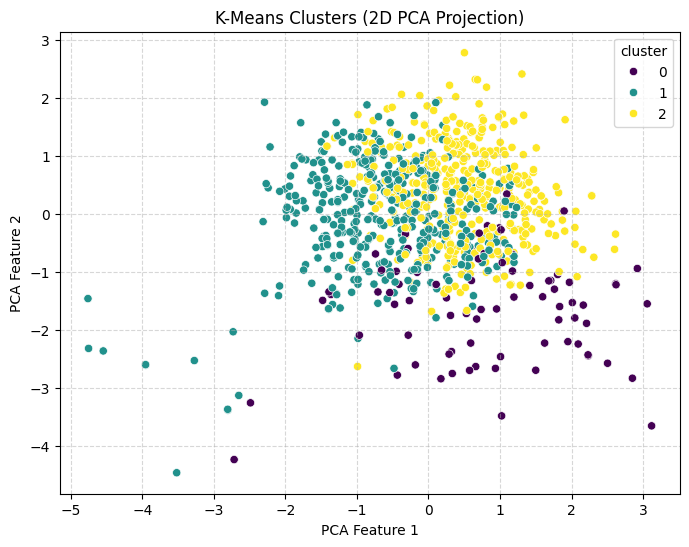

In [136]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_processed = preprocessor.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_processed)
print("Samples per cluster:")
print(df['cluster'].value_counts())

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['cluster'],
    palette='viridis',
)
plt.title('K-Means Clusters (2D PCA Projection)')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

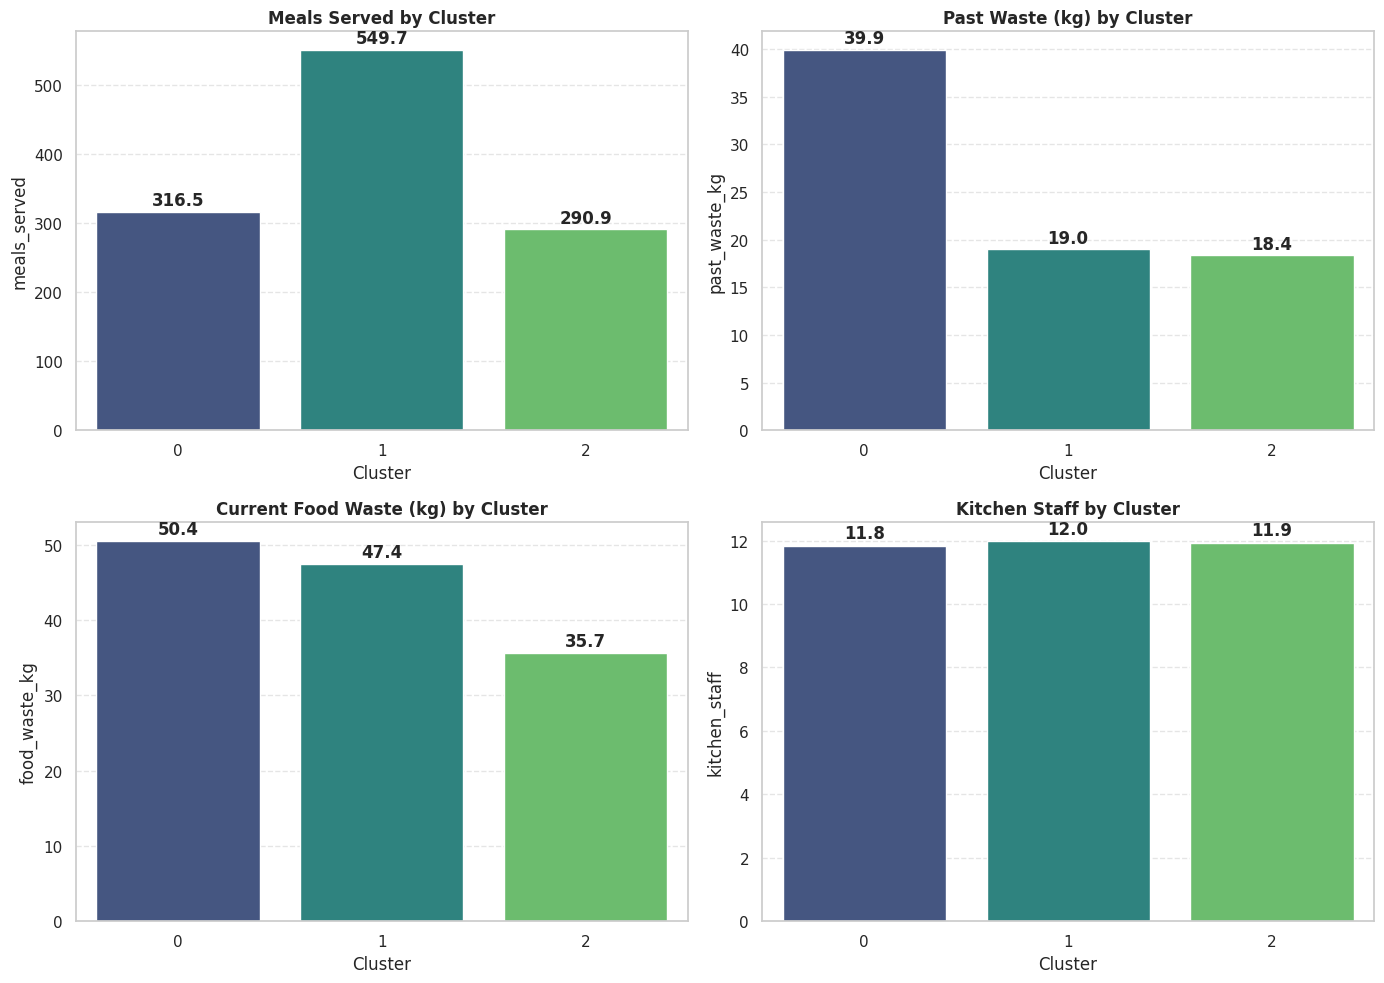

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features = ['meals_served', 'past_waste_kg', 'food_waste_kg', 'kitchen_staff']
titles = ['Meals Served by Cluster', 'Past Waste (kg) by Cluster',
          'Current Food Waste (kg) by Cluster', 'Kitchen Staff by Cluster']


for idx, col in enumerate(features):
    ax = axes[idx]
    sns.barplot(data=df, x='Cluster', y=col, ax=ax, ci=None, palette='viridis')
    ax.set_title(titles[idx], fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)


    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.text(p.get_x() + p.get_width() / 2.0, height + (height * 0.01),
                    f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Model selection/Comparison analysis

In [143]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Neural Network'],
    'R2 Score': [lr_r2, dt_r2, nn_r2],
    'MSE Loss' : [mse_lr,mse_dt,mse_nn],
    'RMSE Loss': [rmse_lr,rmse_dt,rmse_nn],
    'MAE Loss': [mae_lr,mae_dt,mae_nn],
})
comparison_df

,Model,R2 Score,MSE Loss,RMSE Loss,MAE Loss
0,Linear Regression,0.744044,131.143728,11.451800,5.619293
1,Decision Tree,0.716194,145.413133,12.058737,6.213790
2,Neural Network,0.848024,77.867620,8.824263,5.415816


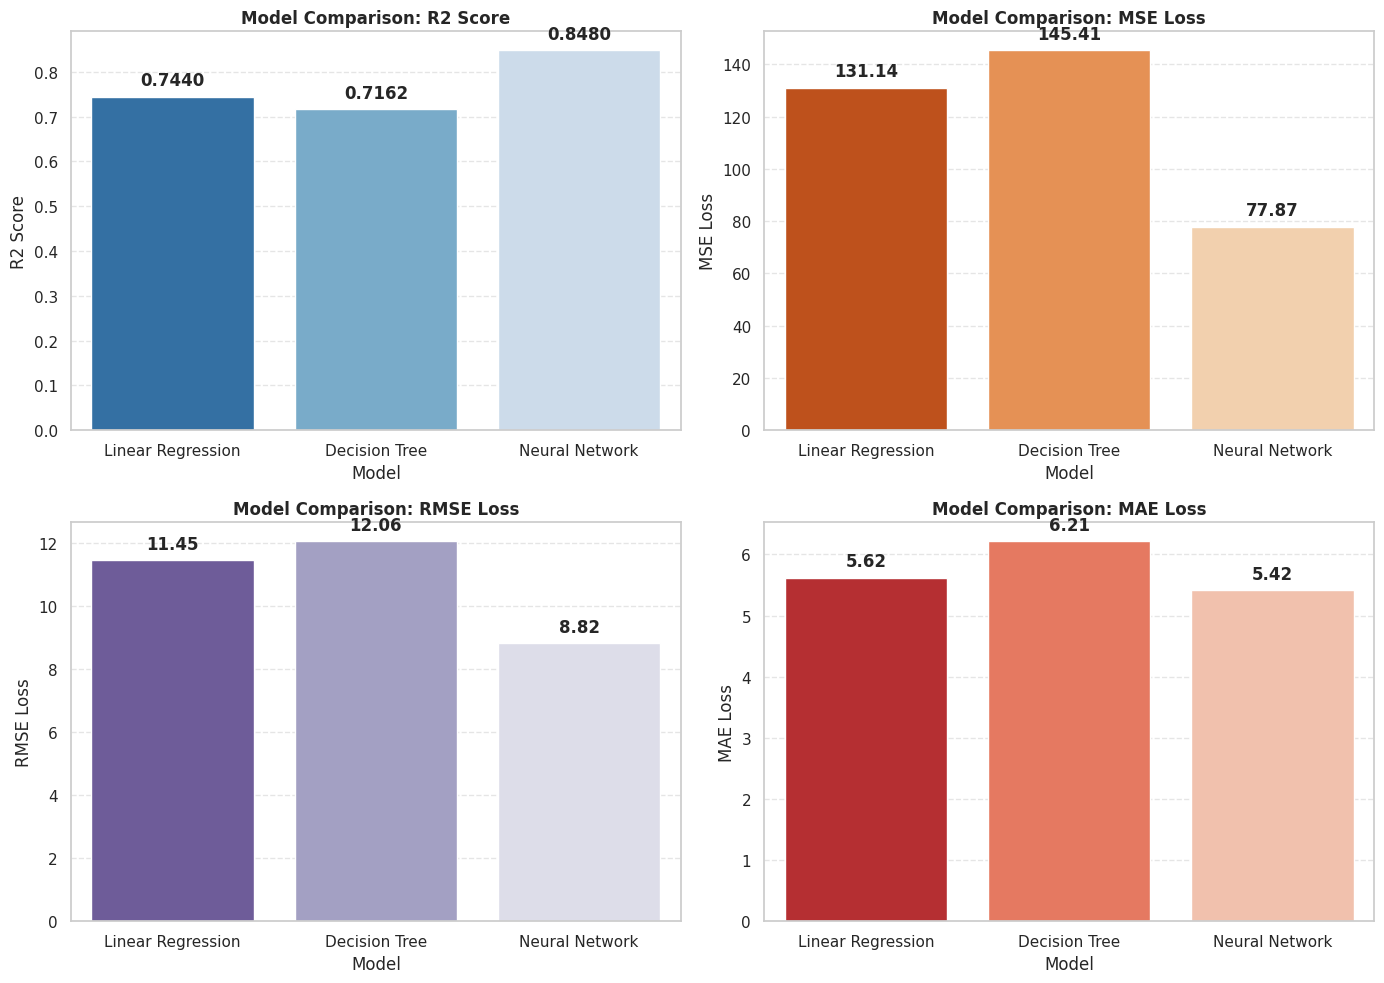

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

metric_cols = [col for col in comparison_df.columns if col != 'Model']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palettes = ['Blues_r', 'Oranges_r', 'Purples_r', 'Reds_r']

for idx, col in enumerate(metric_cols):
    ax = axes[idx]
    sns.barplot(data=comparison_df, x='Model', y=col, ax=ax, palette=palettes[idx % len(palettes)])
    ax.set_title(f'Model Comparison: {col}', fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for p in ax.patches:
        h = p.get_height()
        fmt = f'{h:.4f}' if 'R2' in col else f'{h:.2f}'
        ax.text(p.get_x() + p.get_width() / 2.0, h + (max(comparison_df[col]) * 0.02),
                fmt, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

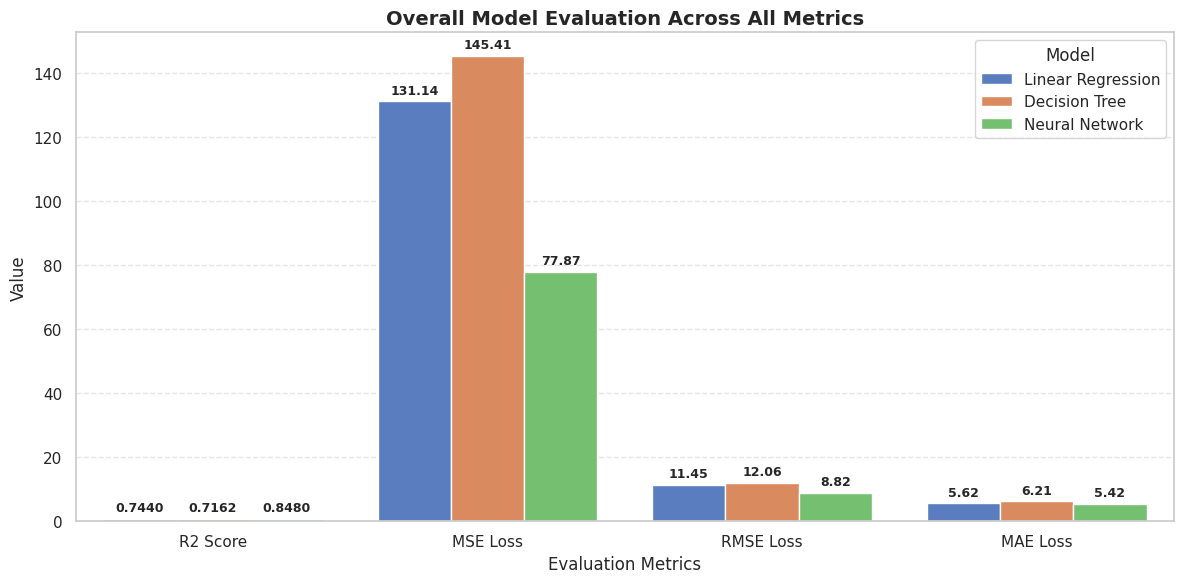

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='muted')

plt.title('Overall Model Evaluation Across All Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Value')
plt.xlabel('Evaluation Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        fmt = f'{height:.4f}' if height < 1 else f'{height:.2f}'
        ax.text(p.get_x() + p.get_width() / 2.0, height + (max(df_melted['Score']) * 0.01),
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(title='Model', loc='upper right')
plt.tight_layout()
plt.show()